Лабораторная работа 1
Исследовательский анализ данных (EDA) и подготовка данных  

Цель:
Освоить полный цикл первичного анализа данных, включая очистку, обработку и визуализацию

Предметная область:
Анализ данных об авиаперелётах, включая информацию о рейсах, времени вылета и задержках

Цель анализа:
Выявить факторы, влияющие на задержки рейсов, и подготовить данные для дальнейшего моделирования

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Airline_Delay_Cause.csv")

df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,7,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",33.0,2.0,0.92,1.00,...,0.0,0.00,0.0,0.0,129.0,98.0,23.0,8.0,0.0,0.0
1,2022,7,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",78.0,25.0,11.80,0.72,...,0.0,7.48,0.0,0.0,1664.0,887.0,52.0,224.0,0.0,501.0
2,2022,7,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",124.0,19.0,5.84,1.00,...,0.0,5.40,5.0,4.0,1523.0,388.0,35.0,511.0,0.0,589.0
3,2022,7,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",67.0,10.0,1.32,1.00,...,1.0,4.28,0.0,1.0,657.0,103.0,82.0,93.0,25.0,354.0
4,2022,7,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",174.0,30.0,18.10,5.75,...,0.0,2.55,1.0,0.0,2462.0,1686.0,310.0,139.0,0.0,327.0


Подключились к датасету

In [4]:
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 101315 entries, 0 to 101314
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 101315 non-null  int64  
 1   month                101315 non-null  int64  
 2   carrier              101315 non-null  str    
 3   carrier_name         101315 non-null  str    
 4   airport              101315 non-null  str    
 5   airport_name         101315 non-null  str    
 6   arr_flights          101157 non-null  float64
 7   arr_del15            100960 non-null  float64
 8   carrier_ct           101157 non-null  float64
 9   weather_ct           101157 non-null  float64
 10  nas_ct               101157 non-null  float64
 11  security_ct          101157 non-null  float64
 12  late_aircraft_ct     101157 non-null  float64
 13  arr_cancelled        101157 non-null  float64
 14  arr_diverted         101157 non-null  float64
 15  arr_delay            101157 

(101315, 21)

Первичный анализ данных
Датасет содержит информацию о рейсах, включая время вылета, авиакомпанию и задержки.
Были изучены:
1 типы данных
2 размер датасета
3 основные статистические показатели

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

arr_del15              355
weather_ct             158
carrier_ct             158
arr_flights            158
security_ct            158
weather_delay          158
arr_diverted           158
arr_delay              158
carrier_delay          158
security_delay         158
nas_ct                 158
late_aircraft_ct       158
arr_cancelled          158
late_aircraft_delay    158
nas_delay              158
dtype: int64

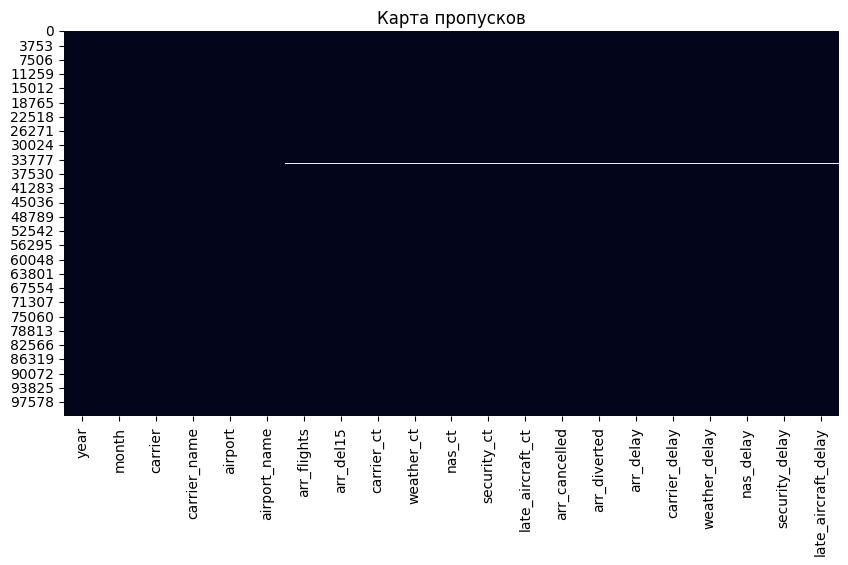

In [14]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Карта пропусков")
plt.show()

In [15]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

arr_del15              0.350392
weather_ct             0.155949
carrier_ct             0.155949
arr_flights            0.155949
security_ct            0.155949
weather_delay          0.155949
arr_diverted           0.155949
arr_delay              0.155949
carrier_delay          0.155949
security_delay         0.155949
nas_ct                 0.155949
late_aircraft_ct       0.155949
arr_cancelled          0.155949
late_aircraft_delay    0.155949
nas_delay              0.155949
airport                0.000000
month                  0.000000
year                   0.000000
carrier_name           0.000000
carrier                0.000000
airport_name           0.000000
dtype: float64

Анализ пропусков
В данных присутствуют пропущенные значения.

Использованы методы:
подсчёт количества пропусков
визуализация (heatmap)

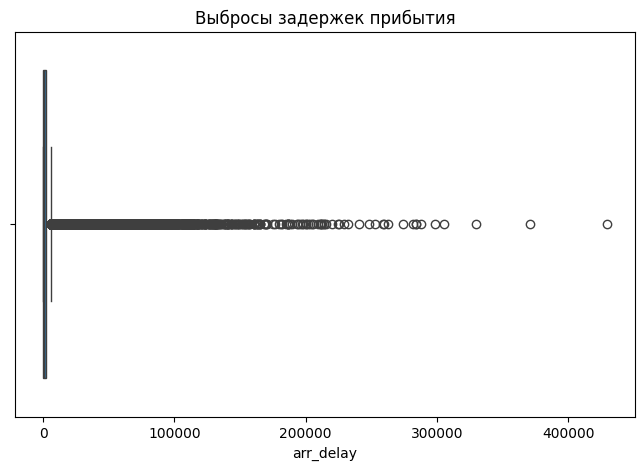

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['arr_delay'])
plt.title("Выбросы задержек прибытия")
plt.show()

In [27]:
Q1 = df['arr_delay'].quantile(0.25)
Q3 = df['arr_delay'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['arr_delay'] < Q1 - 1.5*IQR) | (df['arr_delay'] > Q3 + 1.5*IQR)]

outliers.shape

(5865, 25)

Анализ выбросов
Выбросы были обнаружены с помощью:
boxplot
метода межквартильного размаха (IQR)

In [21]:
df = df.fillna(0)
df = df[(df['arr_delay'] >= Q1 - 1.5*IQR) & (df['arr_delay'] <= Q3 + 1.5*IQR)]

Очистка данных
Пропущенные значения заменены на 0
Выбросы удалены

In [26]:
df['Date'] = pd.to_datetime(df[['year','month']].assign(day=1))
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Delay_per_flight'] = df['arr_delay'] / (df['arr_flights'] + 1)
df['Delay_ratio'] = df['arr_del15'] / (df['arr_flights'] + 1)

Feature Engineering

Были созданы новые признаки:
День недели
Средняя задержка на рейс
Доля задержанных рейсов 

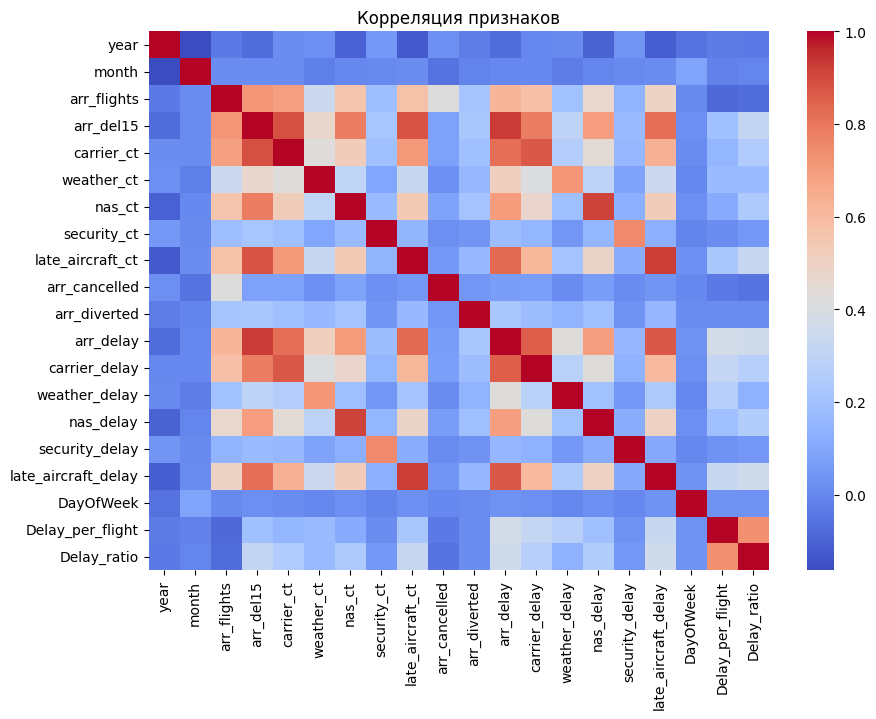

In [30]:
num_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10,7))
sns.heatmap(num_df.corr(), cmap="coolwarm")
plt.title("Корреляция признаков")
plt.show()

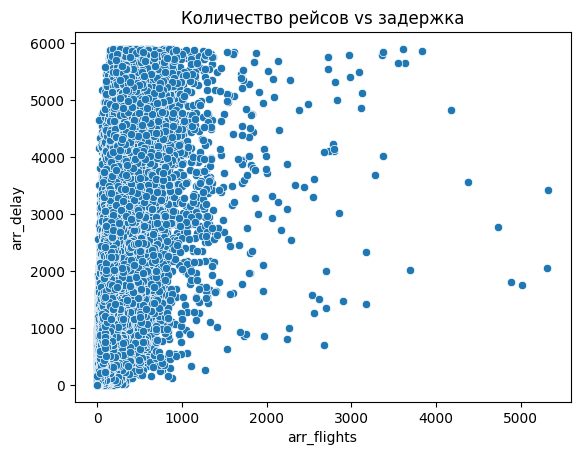

In [31]:
sns.scatterplot(x=df['arr_flights'], y=df['arr_delay'])
plt.title("Количество рейсов vs задержка")
plt.show()

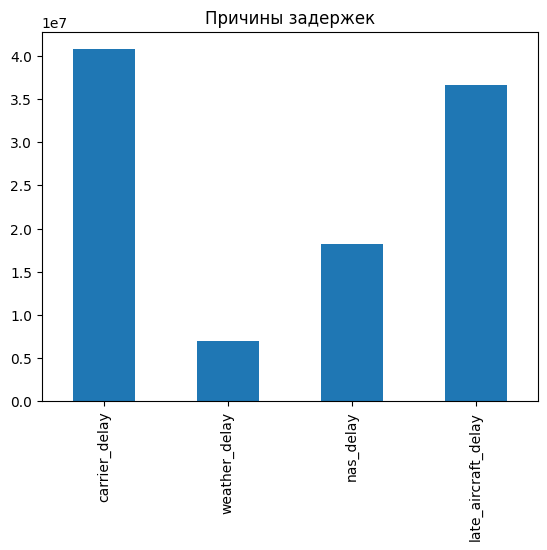

In [32]:
delay_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'late_aircraft_delay']
df[delay_cols].sum().plot(kind='bar')
plt.title("Причины задержек")
plt.show()

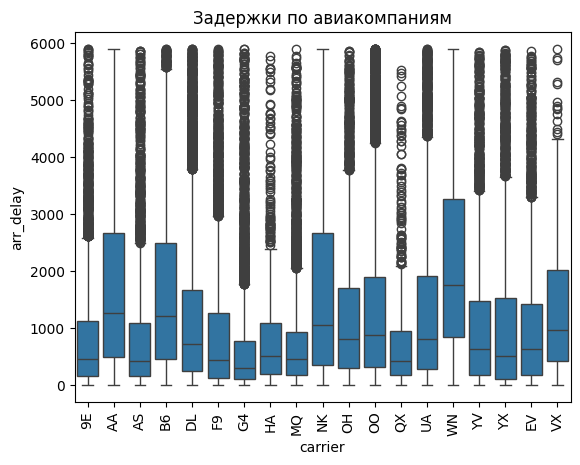

In [33]:
sns.boxplot(x='carrier', y='arr_delay', data=df)
plt.xticks(rotation=90)
plt.title("Задержки по авиакомпаниям")
plt.show()

Аналитические выводы:
Количество рейсов влияет на общий уровень задержек 
Основными причинами задержек являются погодные условия и технические проблемы
Некоторые авиакомпании имеют более высокий уровень задержек
Наличие выбросов влияет на распределение данных
Новые признаки позволяют лучше анализировать данные

Итог
В ходе лабораторной работы был выполнен исследовательский анализ данных

Были проведены:
анализ структуры данных
обработка пропусков
выявление и удаление выбросов
создание новых признаков
визуализация зависимостей